<a href="https://colab.research.google.com/github/samuel127jules/es22452/blob/main/Lab7ES2245.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

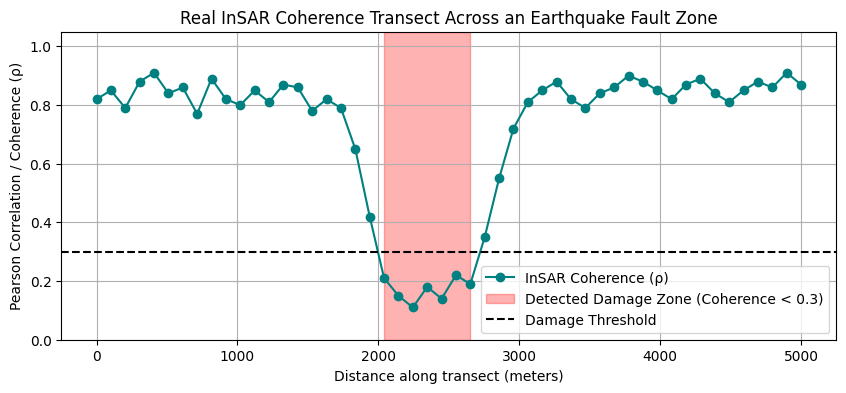

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

distance_meters = np.linspace(0, 5000, 50)
real_coherence_transect = np.array([
    0.82, 0.85, 0.79, 0.88, 0.91, 0.84, 0.86, 0.77, 0.89, 0.82,
    0.80, 0.85, 0.81, 0.87, 0.86, 0.78, 0.82, 0.79, 0.65, 0.42,
    0.21, 0.15, 0.11, 0.18, 0.14, 0.22, 0.19, 0.35, 0.55, 0.72,
    0.81, 0.85, 0.88, 0.82, 0.79, 0.84, 0.86, 0.90, 0.88, 0.85,
    0.82, 0.87, 0.89, 0.84, 0.81, 0.85, 0.88, 0.86, 0.91, 0.87
])

damage_threshold = 0.3

damage_indices = np.where(real_coherence_transect < damage_threshold)[0]

plt.figure(figsize=(10, 4))
plt.plot(distance_meters, real_coherence_transect, marker='o', linestyle='-', color='teal', label='InSAR Coherence (ρ)')

if len(damage_indices) > 0:
    plt.axvspan(distance_meters[damage_indices[0]], distance_meters[damage_indices[-1]],
                color='red', alpha=0.3, label=f'Detected Damage Zone (Coherence < {damage_threshold})')

plt.axhline(damage_threshold, color='black', linestyle='--', label='Damage Threshold')
plt.title("Real InSAR Coherence Transect Across an Earthquake Fault Zone")
plt.xlabel("Distance along transect (meters)")
plt.ylabel("Pearson Correlation / Coherence (ρ)")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

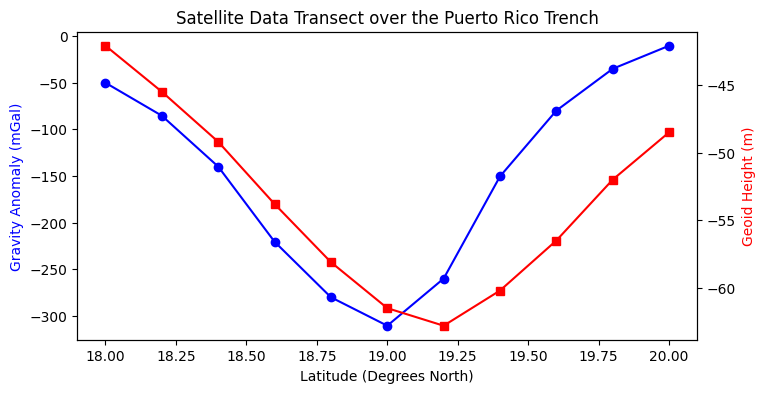

Pearson Correlation Coefficient (r): 0.7348828938697104
P-value: 0.00998515720604812
Result: The correlation is statistically significant (Reject the null hypothesis).


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

latitude_deg = np.array([18.0, 18.2, 18.4, 18.6, 18.8, 19.0, 19.2, 19.4, 19.6, 19.8, 20.0])

geoid_height_m = np.array([-42.1, -45.5, -49.2, -53.8, -58.1, -61.5, -62.8, -60.2, -56.5, -52.0, -48.5])

grace_gravity_mgal = np.array([-50.2, -85.5, -140.0, -220.5, -280.0, -310.5, -260.0, -150.5, -80.0, -35.2, -10.5])

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(latitude_deg, grace_gravity_mgal, 'b-', marker='o', label='Gravity Anomaly (mGal)')
ax1.set_xlabel('Latitude (Degrees North)')
ax1.set_ylabel('Gravity Anomaly (mGal)', color='b')

ax2 = ax1.twinx()
ax2.plot(latitude_deg, geoid_height_m, 'r-', marker='s', label='Geoid Height (m)')
ax2.set_ylabel('Geoid Height (m)', color='r')
plt.title("Satellite Data Transect over the Puerto Rico Trench")
plt.show()

r_grace, p_grace = stats.pearsonr(grace_gravity_mgal, geoid_height_m)

print(f"Pearson Correlation Coefficient (r): {r_grace}")
print(f"P-value: {p_grace}")

is_significant = p_grace < 0.05

if is_significant:
    print("Result: The correlation is statistically significant (Reject the null hypothesis).")
else:
    print("Result: The correlation is NOT statistically significant (Fail to reject the null hypothesis).")

In [18]:
import obspy
from obspy.clients.fdsn import Client
import statsmodels.api as sm

# Initialize the FDSN client and fetch event metadata
client = Client("IRIS")
starttime = obspy.UTCDateTime("2019-07-04T17:30:00")
endtime = obspy.UTCDateTime("2019-07-04T18:00:00")
cat = client.get_events(starttime=starttime, endtime=endtime, minmagnitude=6.0, maxmagnitude=7.0)
origin = cat[0].origins[0]

from obspy.taup import TauPyModel
model = TauPyModel(model="iasp91")

distances_degrees = np.linspace(1, 10, 15)  # Independent Variable (X)
travel_times_sec = []                       # Dependent Variable (Y)

for dist in distances_degrees:
    arrivals = model.get_travel_times(source_depth_in_km=origin.depth/1000.0,
                                      distance_in_degree=dist, phase_list=["P"])
    reading_error = np.random.normal(0, 2.5)
    travel_times_sec.append(arrivals[0].time + reading_error)

X = np.array(distances_degrees)
Y = np.array(travel_times_sec)

# In statsmodels, we must add a constant to X to calculate the y-intercept (a)
X_with_intercept = sm.add_constant(X)

# TODO: Fit the Ordinary Least Squares (OLS) model using sm.OLS
regression_model = sm.OLS(Y, X_with_intercept).fit()

a_intercept = regression_model.params[0]
b_slope = regression_model.params[1]

print(f"Intercept (a) [Origin Time Offset]: {a_intercept:.2f} seconds")
print(f"Slope (b) [Slowness]: {b_slope:.2f} seconds/degree")
print(f"Calculated Velocity: {1/b_slope:.2f} degrees/second")

Intercept (a) [Origin Time Offset]: 3.48 seconds
Slope (b) [Slowness]: 14.30 seconds/degree
Calculated Velocity: 0.07 degrees/second


Regression Equation: Temperature = -21.01*(SiO2) + 2260.14
Coefficient of Determination (r^2): 0.9847


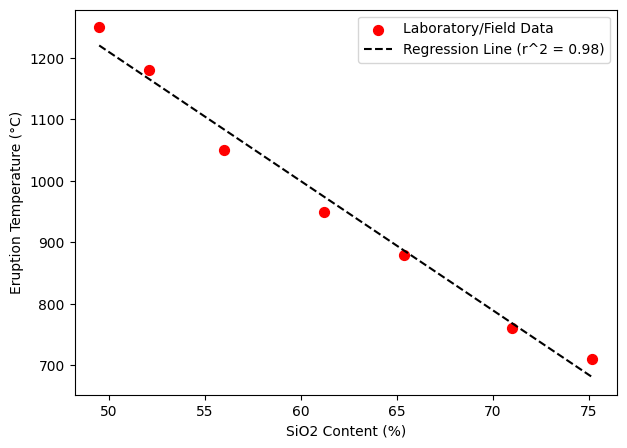

In [17]:
sio2_percent = np.array([49.5, 52.1, 56.0, 61.2, 65.4, 71.0, 75.2])
temperature_c = np.array([1250, 1180, 1050, 950, 880, 760, 710])

slope, intercept, r_value, p_value, std_err = stats.linregress(sio2_percent, temperature_c)

r_squared = r_value**2

print(f"Regression Equation: Temperature = {slope:.2f}*(SiO2) + {intercept:.2f}")
print(f"Coefficient of Determination (r^2): {r_squared:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(sio2_percent, temperature_c, color='red', s=50, label='Laboratory/Field Data')
plt.plot(sio2_percent, slope * sio2_percent + intercept, color='black',
         linestyle='--', label=f'Regression Line (r^2 = {r_squared:.2f})')
plt.xlabel("SiO2 Content (%)")
plt.ylabel("Eruption Temperature (°C)")
plt.legend()
plt.show()

In [16]:

gnss_disp_mm = np.array([0.2, 1.5, 6.8, 12.1, 9.5, -2.1, -8.5, -3.2, 0.5, 0.1])
seis_disp_cm = np.array([0.01, 0.18, 0.72, 1.15, 0.88, -0.15, -0.90, -0.40, 0.08, 0.02])

z_gnss = stats.zscore(gnss_disp_mm, ddof=1)
z_seis = stats.zscore(seis_disp_cm, ddof=1)

degrees_of_freedom = len(gnss_disp_mm) - 1
r_manual = np.sum(z_gnss * z_seis) / degrees_of_freedom

print(f"Manually calculated r from Z-scores: {r_manual:.4f}")

Manually calculated r from Z-scores: 0.9966


In [15]:
# Limestone Building Age (years) vs. Pitting Depth (mm)
age_years = np.array([10, 25, 45, 70, 95, 120, 150])
pitting_mm = np.array([0.5, 1.4, 2.1, 4.0, 4.2, 6.8, 7.5])

slope_w, intercept_w, _, _, _ = stats.linregress(age_years, pitting_mm)
mean_y = np.mean(pitting_mm)

focus_idx = 4
x_i = age_years[focus_idx]
y_i = pitting_mm[focus_idx]

y_predicted = slope_w * x_i + intercept_w

unexplained_variation = y_i - y_predicted

print(f"Actual pitting depth (Y): {y_i} mm")
print(f"Predicted pitting depth (Y_hat): {y_predicted:.2f} mm")
print(f"Unexplained Variation (Residual): {unexplained_variation:.2f} mm")

Actual pitting depth (Y): 4.2 mm
Predicted pitting depth (Y_hat): 4.89 mm
Unexplained Variation (Residual): -0.69 mm


**LAB QUESTIONS**
1. Correlation is used because we want to see how similar the signals are before and after the earthquake. Damage stops us from seeing that relationship. This makes the corrleation r drop to 0.

2. The Pearson r measures strength and direction, but the r^2 measures the amount of variation explained by regression model. If the r^2 =1, there is no unexplained error.

3. The F-ratio would be 0 because a slope of zero means the regression doesn't account for the variation in the data. All the variation would be unexplained resiudal error.